# ICS 2405: Knowledge-Based Systmes

## resampling - making `more` from `less`:
> evaluationg models continued

if we content ourselves with a **single train-test** split, that single step provides and
determines both the data we can train from and our testing environment. however, we might get (un)lucky and get a very good train-test split.
eg a very hard training data and very easy testing data. this strategy for evaluation, is aimed at generating multiple estimates for evaluation - that would need multiple datasets. we find a way to make one dataset to be more than enough regardless of how little it could be.

## 1 - cross-validation:

this is a basic ml technique to generating multiple datasets from a seemingly small dataset.  
cross-validation takes a number of *folds* eg for a 3-fold cross-validation, we’ll take an entire set of
labeled data and shake it up. we’ll let the data fall randomly—as evenly as possible—into
the three categories (buckets): BI, BII, and BIII.

<div style="display: flex;">
    <img src="cross-bukects.png" alt="cross-validation buckets" style="margin-right: 20px; width: 500px; height: auto;"/>
    <img src="train-test-split.png" alt="train-test split" style="width: 500px; height: auto;"/>
</div>


#### how cross-validation works:
> tldr; we use each cross-validation bucket, in turn, as our test data. we train
on the remainder.

1. take bucket `BI` and put it to the side. Put `BII` and `BIII` together and use them as our
training set. train `ModelOne` — from that combined training set. evaluate ModelOne on bucket BI and record the performance as `EvalOne`.
2. take `BII` and put it to the side. put buckets `BI` and `BIII` together and use them as training set. train `ModelTwo` from that combined training set. evaluate `ModelTwo` on bucket BII and record the performance as `EvalTwo`.

3. take bucket `BIII` and put it to the side. put `BI` and `BII` together as our training set.
Train ModelThree from that combined training set. Now, evaluate `ModelThree` on BIII
and record the performance as `EvalThree` ..



### putting it together and `sklearn`:
we’ve recorded three performance values. it takes a a few vlaues we can do graphing them and summarizing them statistically. 
- graphing them can help us understand how variable our performance is with respect to different training and
testing datasets. it tells us something about how our model, our training sets, and our
testing sets interact. with a very wide spread in our performance measures, we would
be justified in being skeptical of any single performance score for our system.
- if the scores are all similar, we have some certainty that, regardless of the specific
train-test split, our system’s performance will be similar.

> ##### caveat + `sklearn` + `k-fold cross-validation`:
> the random sampling
is done without replacement and the train-test splits are all dependent on each other. this
breaks some of the usual assumptions we make.  
> what we’ve described is `3-fold` cross-validation. this technique is
k-fold cross-validation — `k-fold` CV or just k-CV for short. the amount
of cross-validation we do depends on a few factors including the amount of data we have.
3-, 5-, and 10-fold CV are commonly used and recommended.
> 

In [1]:
# setup
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import (datasets, model_selection as skms, linear_model, metrics, neighbors)

In [2]:
diabetes = datasets.load_diabetes()

##### a 5-fold CV with sklearn:  

In [3]:
# data, model, fit & cv-score
model = neighbors.KNeighborsRegressor(10)
skms.cross_val_score(model, diabetes.data, diabetes.target, cv=5, scoring='neg_mean_squared_error')
# notes:
# defaults for cross_val_score are
# cv=3 fold, no shuffle, stratified if classifier
# model.score by default (regressors: r2, classifiers: accuracy)

array([-3206.7541573 , -3426.43134831, -3587.94215909, -3039.49443182,
       -3282.60159091])

### *note*:
> the default value for the `cv` argument to `cross_val_score` is `None`.
> `cv`: **int** or **None** or others. determines the cross-validation splitting strategy.
possible inputs for cv are:
> - None, to use the default 3-fold cross validation,
> - Integer, to specify the number of folds in a (Stratified)KFold,
> - Others.  
> for or integer/None inputs, if the estimator is a **classifier** and `y` is either `binary` or
`multiclass`, `StratifiedKFold` is used. in all other cases, `KFold` is used

### take away:
(1) by default we’re doing 3-fold CV and  
(2) for classification problems, sklearn uses *stratification*.


> NOTE:  
> `scoring='neg_mean_squared_error'` argument recall what 
 mean squared error (MSE) does. and , we have to reconcile “error up, bad” with “score up, good.” to do that, sklearn negates
the MSE to go from an error measure to a score. the scores are all negative, but a bigger
score is better.

## 2 - stratification: 
we can have cross-validation in a classification context. here, we tell
`cross_val_score` to use 5-fold CV:

In [4]:
iris = datasets.load_iris()
model = neighbors.KNeighborsClassifier(10)
skms.cross_val_score(model, iris.data, iris.target, cv=5) # scoring = stratifiedkfold by default coz this is a classifier

array([0.96666667, 1.        , 1.        , 0.93333333, 1.        ])

from the above the cross-validation was done in a stratified manner because it is
the default for **classifiers** in `sklearn`...   
**stratification** means that when we make our *training-testing* splits for cross-validation, we want to respect the
proportions of the targets that are present in our data.  

#### example two-fold:

In [5]:
# not stratified
pet = np.array(['cat', 'dog', 'cat', 'dog', 'dog', 'dog'])

list_folds = list(skms.KFold(2).split(pet))

training_idxs = np.array(list_folds)[:, 0, :]
print(pet[training_idxs])

[['dog' 'dog' 'dog']
 ['cat' 'dog' 'cat']]


#### problem: 
notice that there were no cats in the first fold. that’s not
great. if that were our target, we would have no examples to learn about cats. that is a problem - that can’t be good. **stratified sampling** enforces fair play among the cats and dogs:

In [6]:
# stratified
# note: typically this is behind the scenes
# making StratifiedKFold produce readable output
# requires some trickery. feel free to ignore.
pet = np.array(['cat', 'dog', 'cat', 'dog', 'dog', 'dog'])

idxs = np.array(list(skms.StratifiedKFold(2).split(np.ones_like(pet), pet)))

training_idxs = idxs[:, 0, :]

print(pet[training_idxs])

[['cat' 'dog' 'dog']
 ['cat' 'dog' 'dog']]


#### verdict - stratification
both folds have a balanced number of cats and dogs, equal to their proportion in
the overall dataset.  

stratification ensures that we have the same (or nearly the same, once
we round off uneven splits) percent of dogs and cats in each of our training sets as we do in
our entire, available population. without stratification, we could end up having too few
(or even none) of a target class - we don’t expect that training data to lead to a good model.
stratification is particularly useful when:  
1. we have limited data overall or
2. we have classes that are poorly represented in our dataset.

poor representation might be due to
rareness—it
might be due to our data collection processes. having a limited total amount of data makes
everything rare, in a sense.
how does the default stratification apply to the iris dataset? it means that
when we perform the cross-validation splits, we can be sure that each of the training sets
has a balanced representation from each of the three possible target flowers. what if we
don’t want stratification? it’s slightly more tricky, but we can do it:

In [7]:
# running nonstratified CV
iris = datasets.load_iris()
model = neighbors.KNeighborsClassifier(10) 

non_strat_kf = skms.KFold(5)

skms.cross_val_score(model, iris.data, iris.target, cv=non_strat_kf)

array([1.        , 1.        , 0.86666667, 0.96666667, 0.76666667])

### 3 - repeated train-test splits:
in the case of train-test splits, we generally don’t know ahead of time how well we
expect to perform  

> why do we want to repeat a train-test
split step?
this is beacause we are we relying on randomness, and we are subject to variation: several different
train-test splits might give different results. in essesnece we don’t know ahead of time
what the outcomes are.we have use tools at our disposal that
we can pull out when confronted with unknown randomness. do the random thing many
times and see what happens.
>

we can investigate the variation due to the train-test split
by making many train-test splits and looking at different results.  
the multiple values—one per train-test split—get us a distribution of the results and
how often they occur. repeated train-test splits get us a distribution of our
evaluation measure—whether it is accuracy, root-mean-squared-error, or something else.
The distribution is not over every possible source of variation. it is simply taking into
account one difference due to randomness: how we picked the training and testing data.
we can see how variable our result is due to the randomness of making a train-test split:

In [9]:
linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()

scores = []
for r in range(10):
    tts = skms.train_test_split(diabetes.data, diabetes.target, test_size=.25)
    (diabetes_train_ftrs, diabetes_test_ftrs, diabetes_train_tgt, diabetes_test_tgt) = tts

    fit = linreg.fit(diabetes_train_ftrs, diabetes_train_tgt)
    preds = fit.predict(diabetes_test_ftrs)
    score = metrics.mean_squared_error(diabetes_test_tgt, preds)
    scores.append(score)


scores = pd.Series(np.sqrt(sorted(scores)))
df = pd.DataFrame({'RMSE':scores})
df.index.name = 'Repeat'
display(df.T)

Repeat,0,1,2,3,4,5,6,7,8,9
RMSE,50.738284,51.245528,51.930607,52.511553,53.015658,53.778459,55.367882,55.449915,57.659687,57.665539


### some plots:

Text(0.5, 17.722222222222214, 'Over Repeated\nTrain-Test Splits')

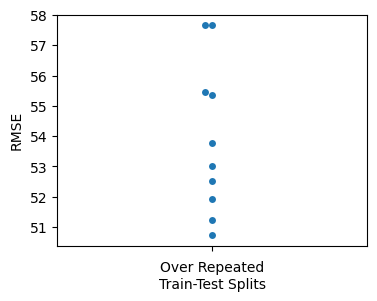

In [10]:
ax = plt.figure(figsize=(4, 3)).gca()
sns.swarmplot(y='RMSE', data=df, ax=ax)
ax.set_xlabel('Over Repeated\nTrain-Test Splits')

In [11]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
RMSE,10.0,53.936311,2.505639,50.738284,52.075843,53.397058,55.429407,57.665539


#### explaining things:
you have to understand the scale of the data to evaluate.  
at first, we might think that this data is pretty spread out, but upon further review, we see that it is
clustered in the mid-to-upper 50s. whether that is “a lot” depends on size of the **RMSE**
values—the mean is near 55, so we are in the ballpark of ±10%. that’s large enough to
warrant our attention.  

Python: we can rewrite the score-computing code above
with a ***list comprehension*** instead of a ***loop***.   
(1) take the contents of the loop and turn it into a function and  
(2) use that function repeatedly in a list comprehension. 

> this rewrite gets us a bit of performance gain—not for
the resource optimization. the biggest win is that we’ve given a name to our process of
making a `train-test` split, fitting, predicting, and evaluating. ehe,
naming is one of the most powerful/difficult things we can do in a computer program. defining a
function also gives us a single entity that we can test for resource use and reuse in
other code.

In [12]:
def tts_fit_score(model, data, msr, test_size=.25):
    'apply a train-test split to fit model on data and eval with MSR'
    tts = skms.train_test_split(data.data, data.target, test_size=test_size)
    
    (train_ftrs, test_ftrs, train_tgt, test_tgt) = tts
    fit = linreg.fit(train_ftrs, train_tgt)
    preds = fit.predict(test_ftrs)
    score = msr(test_tgt, preds)
    return score

linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()
scores = [tts_fit_score(linreg, diabetes, metrics.mean_squared_error) for i in range(10)]

print(np.mean(scores))

3058.0435877146797


with `k-CV`, we will get one, and only one, prediction for each and every example.   
each example is in precisely one test bucket. the predictions for the whole dataset will be
aggregated from the `k` models that are developed on different sets of data. 

with `repeated train-test splits`, we may completely ignore training or predicting on some examples and
make repeated predictions on other examples - in repeated train-test splits, it is all subject to the randomness of our selection process.

RTTS may have duplication between repeats:

<div style="display: flex;">
    <!-- <img src="cross-bukects.png" alt="cross-validation buckets" style="margin-right: 20px; width: 500px; height: auto;"/> -->
    <img src="rtts.png" alt="repaeted train-test split" style="width: 500px; height: auto;"/>
</div>

### 4 - shuffling:

> it is annoying to manage a repeated looping to make multiple `train-test splits` was a bit annoying - there are many places we could make a mistake  
> we can pass in a **ShuffleSplit** data-splitter to the `cv` argument of
`cross_val_score`, we get precisely the effect of the algorithm hard-coded above:
> 

,count,mean,std,min,25%,50%,75%,max
RMSE,10.0,55.070464,2.765196,48.139355,54.315729,56.212579,56.382967,57.65824


Text(0.5, 37.52222222222222, 'Over Repeated\nTrain-Test Splits')

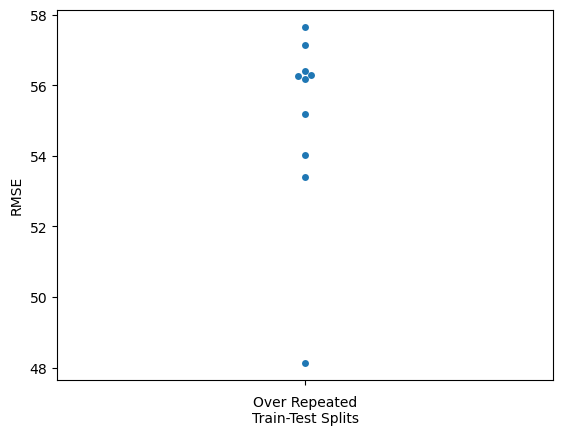

In [14]:
linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()

# nondefault cv= argument
ss = skms.ShuffleSplit(test_size=.25) # default, 10 splits
scores = skms.cross_val_score(linreg, diabetes.data, diabetes.target, cv=ss, scoring='neg_mean_squared_error')

scores = pd.Series(np.sqrt(-scores))
df = pd.DataFrame({'RMSE':scores})
df.index.name = 'Repeat'

display(df.describe().T)
ax = sns.swarmplot(y='RMSE', data=df)
ax.set_xlabel('Over Repeated\nTrain-Test Splits')

the slight differences with our manual version are due to randomly selecting the
train-test splits.  
now, another way that randomness that the computer uses when we ask it to do
random things - behind the scenes with `ShuffleSplit`:

In [15]:
ss = skms.ShuffleSplit(test_size=.25, random_state=42)

train, test = 0, 1
next(ss.split(diabetes.data))[train][:10]

array([ 16, 408, 432, 316,   3,  18, 355,  60, 398, 124])

`next` because `ShuffleSplit` relies on a **Python generator** to produce
one split after another. saying `next` provides the next data split. after fetching the
next data split, I pick out the training data `[train]` and then the **first ten** examples `[:10]`

In [16]:
ss = skms.ShuffleSplit(test_size=.25, random_state=42)
next(ss.split(diabetes.data))[train][:10]

array([ 16, 408, 432, 316,   3,  18, 355,  60, 398, 124])

### pseudo-random numbers:
the results are the same.
this doestn randomness:  randomness on a computer is often pseudo-random:

it’s a long list of numbers that, when put together, are random enough to fake their randomness. we start at some point in that list and start taking values. 
to an outside observer, they seem pretty random - but if you know the
mechanism, you could actually know what values are coming ahead of time. thus:  
(1) the values we generate will look mostly random  
(2) the process used to generate them is actually deterministic.  

this **determinism** has a nice side effect that we can take advantage
of. if we specify a starting point for the sequence of pseudo-random numbers, we can get a
reproducible list of the not-so-random values. with `random_state`, we are setting
a starting point for `ShuffleSplit` to use when it asks for randomness. we’ll end up getting
the same outputs. 

**repeatable train-test splitting** is very useful for creating reproducible test
cases, and eliminating some degrees of freedom when chasing down bugs.  
two separate runs of `KFolding`:

In [17]:
train, test = 0, 1
kf = skms.KFold(5)

next(kf.split(diabetes.data))[train][:10]

array([89, 90, 91, 92, 93, 94, 95, 96, 97, 98])

In [18]:
kf = skms.KFold(5)
next(kf.split(diabetes.data))[train][:10]

array([89, 90, 91, 92, 93, 94, 95, 96, 97, 98])

the lack of randomness, in places we want randomness, is starting to get a little old. the issue here is the default parameters to `KFold`:

In [20]:
skms.KFold(n_splits=3, shuffle=False, random_state=None)

KFold(n_splits=3, random_state=None, shuffle=False)

### 5 - leave-one-out cross validation:

we can have as many cross-validation buckets as we have examples; eg with 20 examples, we could
potentially make 20 `train-test splits`, do **20 training fits**, do **20 testing rounds**, and get **20
resulting evaluations**.  
this version of **CV** is called `leave-one-out cross-validation` `(LOOCV)`
and it is interesting because all of the models we generate are going to have almost all of
their training data in common. with 20 examples, 90% of the data is shared between any
two training runs.

,count,mean,std,min,25%,50%,75%,max
RMSE,442.0,44.355723,32.19733,0.208637,18.485262,39.548204,63.974315,158.233013


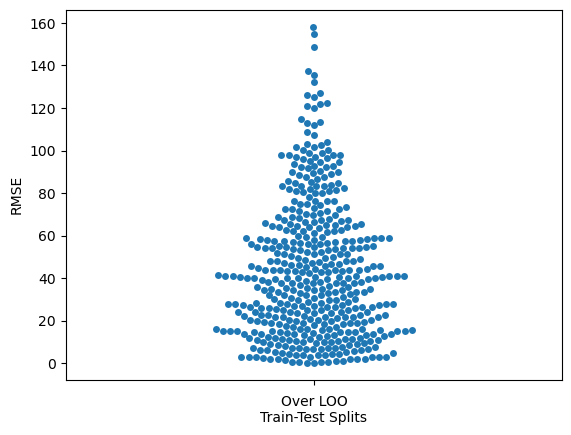

In [21]:
linreg = linear_model.LinearRegression()
diabetes = datasets.load_diabetes()

loo = skms.LeaveOneOut()
scores = skms.cross_val_score(linreg, diabetes.data, diabetes.target, cv=loo, scoring='neg_mean_squared_error')

scores = pd.Series(np.sqrt(-scores))
df = pd.DataFrame({'RMSE':scores})
df.index.name = 'Repeat'

display(df.describe().T)

ax = sns.swarmplot(y='RMSE', data=df)
ax.set_xlabel('Over LOO\nTrain-Test Splits');

*   **Error Analysis:** the model shows about 20 high-error outliers (RMSE > 100), which are resistant to prediction and warrant investigation for common characteristics.
*   **`LOOCV` Properties:** 
    *   It is **deterministic**, making it useful for algorithm comparison.
    *   It is **computationally expensive**, requiring a model to be trained for each data point.
    *   It provides a **low-bias but high-variance** error estimate.
*   **Recommendation:** 5- or 10-fold cross-validation is generally preferred over `LOOCV`.

### end
> more:  
> see notebook on deconstructing error into variance and bias, and complexity curves